# Figure 6: Network Dependence of Explained Variance (hd-EEG)

This notebook reproduces the Figure 6 network-dependence analysis using the saved hd-EEG correlation table in `data/df_results/hd-eeg_metrics/df_correlations_5MOIs_hd-eeg.csv`.

It keeps the same overall strategy as the original notebook:
- restrict to a single radius setting,
- compute explained variance as $\rho^2$,
- test for network effects with a linear mixed-effects model,
- visualize each metric-pair trajectory across stimulated networks with the overall mean and uncertainty overlaid.

To match the old Figure 6 setup as closely as possible with the saved dataframe schema, the analysis below uses `Radius_pre == 100` and `Radius_post == 100`.

In [13]:
from pathlib import Path
import warnings

import matplotlib as mpl
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from IPython.display import display
from scipy.stats import chi2, friedmanchisquare, spearmanr, wilcoxon
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', message='Random effects covariance is singular')

mpl.rcdefaults()
sns.set_style('whitegrid')
mpl.rcParams.update({
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

cwd = Path.cwd().resolve()
if (cwd / 'data').exists():
    project_root = cwd
elif (cwd.parent / 'data').exists():
    project_root = cwd.parent
else:
    raise FileNotFoundError('Could not find project root containing data/.')

correlations_path = project_root / 'data' / 'df_results' / 'hd-eeg_metrics' / 'df_correlations_5MOIs_hd-eeg.csv'
figure_dir = project_root / 'results' / 'figures'
figure_dir.mkdir(parents=True, exist_ok=True)
figure_path = figure_dir / 'Figure_6_network_dependence_hdEEG.png'

network_names = {
    'Default': 'DMN',
    'DorsAttn': 'DAN',
    'SalVentAttn': 'VAN',
    'Cont': 'CON',
    'Limbic': 'LIM',
    'SomMot': 'SMN',
    'Vis': 'VIS',
}
ordered_networks = ['DMN', 'LIM', 'CON', 'DAN', 'VAN', 'SMN', 'VIS']
network_gradient_positions = {network: index + 1 for index, network in enumerate(ordered_networks)}

print(f'Loaded correlations from: {correlations_path}')
print(f'Figure output path: {figure_path}')

Loaded correlations from: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/data/df_results/hd-eeg_metrics/df_correlations_5MOIs_hd-eeg.csv
Figure output path: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/results/figures/Figure_6_network_dependence_hdEEG.png


In [14]:
df_correlations = pd.read_csv(correlations_path)
df_network = df_correlations.loc[
    (df_correlations['Radius_pre'] == 100) & (df_correlations['Radius_post'] == 100)
].copy()

df_network['Explained_Variance'] = df_network['Correlation'] ** 2
df_network['Network'] = df_network['Network'].map(network_names)
df_network = df_network.dropna(subset=['Network'])
df_network['Network'] = pd.Categorical(
    df_network['Network'], categories=ordered_networks, ordered=True
)

network_summary = (
    df_network.groupby('Network', observed=True)['Explained_Variance']
    .agg(['mean', 'std', 'count'])
    .reindex(ordered_networks)
    .reset_index()
    .rename(columns={'mean': 'Mean_Explained_Variance', 'std': 'Std_Explained_Variance'})
)

network_pair_means = (
    df_network.groupby(['Metric_pre', 'Metric_post', 'Network'], observed=True)['Explained_Variance']
    .mean()
    .unstack('Network')
    .reindex(columns=ordered_networks)
    .dropna()
    .reset_index()
)

friedman_result = friedmanchisquare(
    *[network_pair_means[network].to_numpy(dtype=float) for network in ordered_networks]
 )

rsn_difference_results = []
reference_network = 'DMN'
for network in ordered_networks[1:]:
    differences = network_pair_means[network] - network_pair_means[reference_network]
    test_result = wilcoxon(differences, alternative='greater')
    rsn_difference_results.append({
        'Comparison': f'{network} > {reference_network}',
        'Median_Difference': float(np.median(differences)),
        'Mean_Difference': float(np.mean(differences)),
        'Wilcoxon_Statistic': float(test_result.statistic),
        'Wilcoxon_pvalue': float(test_result.pvalue),
    })

rsn_difference_results = pd.DataFrame(rsn_difference_results)

print('Network summary for Radius_pre = Radius_post = 100')
display(network_summary)
print(f'Number of metric-pair profiles used for mean-level tests: {len(network_pair_means)}')
print(
    f'Friedman test across ordered RSNs: chi2 = {friedman_result.statistic:.4f}, '
    f'p = {friedman_result.pvalue:.4g}'
)
print('Mean-level paired comparisons against DMN')
display(rsn_difference_results)

Network summary for Radius_pre = Radius_post = 100


,Network,Mean_Explained_Variance,Std_Explained_Variance,count
0,DMN,0.070967,0.091729,1675
1,LIM,0.072623,0.103760,925
2,CON,0.056306,0.069706,625
3,DAN,0.072938,0.085903,475
4,VAN,0.074215,0.105563,1650
5,SMN,0.077707,0.099170,1875
6,VIS,0.061385,0.078875,600


Number of metric-pair profiles used for mean-level tests: 25
Friedman test across ordered RSNs: chi2 = 38.7257, p = 8.1e-07
Mean-level paired comparisons against DMN


,Comparison,Median_Difference,Mean_Difference,Wilcoxon_Statistic,Wilcoxon_pvalue
0,LIM > DMN,-0.000517,0.001655,194.0,0.205383
1,CON > DMN,-0.013322,-0.014661,35.0,0.999892
2,DAN > DMN,0.003312,0.001971,193.0,0.213071
3,VAN > DMN,0.002727,0.003247,237.0,0.022561
4,SMN > DMN,0.006057,0.006740,266.0,0.002088
5,VIS > DMN,-0.009864,-0.009583,54.0,0.998872


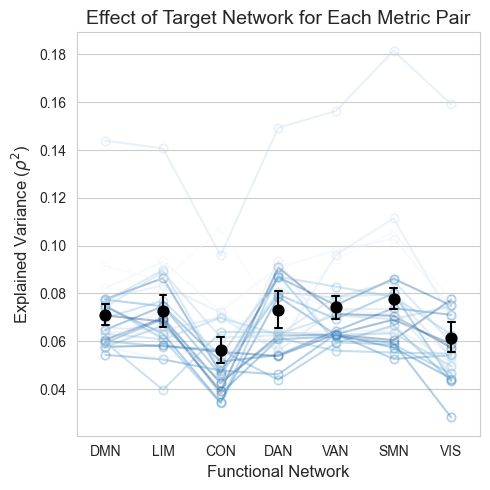

Saved figure to: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/results/figures/Figure_6_network_dependence_hdEEG.png
Number of metric pairs shown: 25


In [17]:
df_raw = df_network.copy()

unique_pairs = (
    df_raw[['Metric_pre', 'Metric_post']]
    .drop_duplicates()
    .sort_values(['Metric_pre', 'Metric_post'])
    .reset_index(drop=True)
)
pair_colors = sns.color_palette('Blues_r', n_colors=len(unique_pairs))
pair_to_color = {
    (row.Metric_pre, row.Metric_post): pair_colors[idx]
    for idx, row in unique_pairs.iterrows()
}

fig, ax = plt.subplots(figsize=(5, 5))
for (pre_metric, post_metric), subset in df_raw.groupby(['Metric_pre', 'Metric_post']):
    mean_values = (
        subset.groupby('Network', observed=True)['Explained_Variance']
        .mean()
        .reindex(ordered_networks)
)
    color = pair_to_color[(pre_metric, post_metric)]
    ax.plot(
        ordered_networks,
        mean_values.values,
        color=color,
        alpha=0.35,
        linewidth=1.5,
        marker='o',
        markersize=6,
        markerfacecolor='none',
        markeredgewidth=1.2,
    )

sns.pointplot(
    data=df_raw,
    x='Network',
    y='Explained_Variance',
    order=ordered_networks,
    estimator=np.mean,
    errorbar=('ci', 95),
    color='black',
    markers='o',
    linestyles='none',
    err_kws={'linewidth': 1.5},
    capsize=0.12,
    ax=ax,
    zorder=5,
    legend=False,
 )

ax.set_title('Effect of Target Network for Each Metric Pair')
ax.set_xlabel('Functional Network')
ax.set_ylabel(r'Explained Variance ($\rho^2$)')

fig.tight_layout()
fig.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved figure to: {figure_path}')
print(f'Number of metric pairs shown: {len(unique_pairs)}')

In [15]:
metric_pair_gradient_results = []
for _, row in network_pair_means.iterrows():
    network_values = row[ordered_networks].to_numpy(dtype=float)
    rho, pvalue = spearmanr(
        np.arange(1, len(ordered_networks) + 1),
        network_values,
    )
    metric_pair_gradient_results.append({
        'Metric_pre': row['Metric_pre'],
        'Metric_post': row['Metric_post'],
        'Spearman_rho': float(rho),
        'Spearman_pvalue': float(pvalue),
    })

metric_pair_gradient_results = pd.DataFrame(metric_pair_gradient_results)
gradient_wilcoxon_result = wilcoxon(
    metric_pair_gradient_results['Spearman_rho'],
    alternative='greater',
)

metric_pair_gradient_summary = pd.Series({
    'Metric_Pairs': int(len(metric_pair_gradient_results)),
    'Median_Spearman_rho': float(metric_pair_gradient_results['Spearman_rho'].median()),
    'Mean_Spearman_rho': float(metric_pair_gradient_results['Spearman_rho'].mean()),
    'Positive_Metric_Pairs': int((metric_pair_gradient_results['Spearman_rho'] > 0).sum()),
    'Wilcoxon_Statistic': float(gradient_wilcoxon_result.statistic),
    'Wilcoxon_OneSided_pvalue': float(gradient_wilcoxon_result.pvalue),
})

print('Metric-pair mean-level gradient summary across ordered RSNs')
display(metric_pair_gradient_summary.to_frame(name='Value'))
display(metric_pair_gradient_results.sort_values('Spearman_rho', ascending=False).reset_index(drop=True))

Metric-pair mean-level gradient summary across ordered RSNs


,Value
Metric_Pairs,25.000000
Median_Spearman_rho,-0.071429
Mean_Spearman_rho,-0.001429
Positive_Metric_Pairs,11.000000
Wilcoxon_Statistic,140.000000
Wilcoxon_OneSided_pvalue,0.612575


,Metric_pre,Metric_post,Spearman_rho,Spearman_pvalue
0,Salience,Salience,0.821429,0.023449
1,Fluidity,ZCR,0.678571,0.093750
2,Complexity,Fluidity,0.571429,0.180202
3,Complexity,Entrainment,0.285714,0.534509
4,ZCR,Fluidity,0.250000,0.588724
5,ZCR,Salience,0.214286,0.644512
6,Fluidity,Salience,0.142857,0.759945
7,Entrainment,Fluidity,0.142857,0.759945
8,Complexity,ZCR,0.107143,0.819151
9,Fluidity,Fluidity,0.071429,0.879048


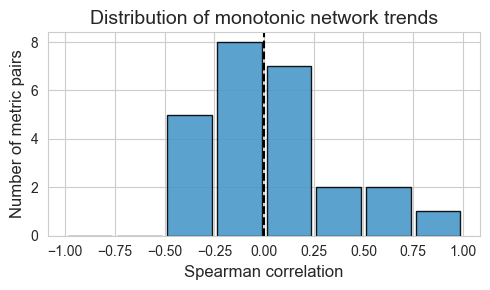

Saved histogram to: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/results/figures/Figure_6_network_dependence_hdEEG_spearman_histogram.png


In [18]:
gradient_histogram_path = figure_dir / 'Figure_6_network_dependence_hdEEG_spearman_histogram.png'

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(
    metric_pair_gradient_results['Spearman_rho'],
    bins=np.linspace(-1.0, 1.0, 9),
    color=plt.get_cmap('Blues')(0.6),
    edgecolor='black',
    linewidth=1.0,
    alpha=0.9,
    rwidth=0.9,
)
ax.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=1.5,
)

ax.set_xlabel('Spearman correlation', fontsize=12)
ax.set_ylabel('Number of metric pairs', fontsize=12)
ax.set_title('Distribution of monotonic network trends', fontsize=14)
ax.tick_params(axis='both', labelsize=10)

fig.tight_layout()
fig.savefig(gradient_histogram_path, dpi=300, bbox_inches='tight', transparent=True)
plt.show()

print(f'Saved histogram to: {gradient_histogram_path}')